In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import os, shutil, random
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
base_path = '/content/drive/MyDrive/dataset'

In [ ]:
random.seed(42)

output_path = '/content/dataset_resnet'
classes = ['organic', 'recyclable']

# hapus folder lama
if os.path.exists(output_path):
    shutil.rmtree(output_path)

for cls in classes:
    class_path = os.path.join(base_path, cls)
    img_list = [f for f in os.listdir(class_path)
                if f.lower().endswith(('.png','.jpg','.jpeg'))]

    random.shuffle(img_list)
    split_index = int(len(img_list) * 0.8)

    train_imgs = img_list[:split_index]
    test_imgs = img_list[split_index:]

    for folder in ['train','test']:
        os.makedirs(os.path.join(output_path, folder, cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_path,'train',cls,img))

    for img in test_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_path,'test',cls,img))

print("Split selesai!")

Split selesai!


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    '/content/dataset_resnet/train',
    target_size=(224,224),
    class_mode='binary'
)

test_gen = test_datagen.flow_from_directory(
    '/content/dataset_resnet/test',
    target_size=(224,224),
    class_mode='binary',
    shuffle=False
)

Found 19764 images belonging to 2 classes.
Found 4941 images belonging to 2 classes.


In [ ]:
base_model = ResNet50(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

for layer in base_model.layers:
    layer.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10
)

Epoch 1/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 303s 467ms/step - accuracy: 0.6189 - loss: 0.6533 - val_accuracy: 0.6661 - val_loss: 0.6149
Epoch 2/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 271s 438ms/step - accuracy: 0.6552 - loss: 0.6261 - val_accuracy: 0.6968 - val_loss: 0.6001
Epoch 3/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 266s 430ms/step - accuracy: 0.6708 - loss: 0.6139 - val_accuracy: 0.7001 - val_loss: 0.5821
Epoch 4/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 267s 433ms/step - accuracy: 0.6735 - loss: 0.6036 - val_accuracy: 0.6934 - val_loss: 0.5844
Epoch 5/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 268s 434ms/step - accuracy: 0.6791 - loss: 0.6023 - val_accuracy: 0.7122 - val_loss: 0.5857
Epoch 6/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 261s 422ms/step - accuracy: 0.6890 - loss: 0.5944 - val_accuracy: 0.7146 - val_loss: 0.5792
Epoch 7/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 257s 416ms/step - accuracy: 0.6902 - loss: 0.5897 - val_accuracy: 0.7248 - val_loss: 0.5535
Epoch 8/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 273s 441ms/step - accuracy: 0.6908 -

In [ ]:
print("TRAIN ACC:", history.history['accuracy'][-1])
print("TEST ACC :", history.history['val_accuracy'][-1])

TRAIN ACC: 0.6964683532714844
TEST ACC : 0.7117992043495178


In [ ]:
# TEST
test_gen.reset()
pred_test = model.predict(test_gen)
y_pred_test = (pred_test > 0.5).astype(int).reshape(-1)
y_true_test = test_gen.classes

# TRAIN
train_gen.reset()
pred_train = model.predict(train_gen)
y_pred_train = (pred_train > 0.5).astype(int).reshape(-1)
y_true_train = train_gen.classes

155/155 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step
618/618 ━━━━━━━━━━━━━━━━━━━━ 257s 416ms/step


In [ ]:
print("\n===== TESTING REPORT =====")
print(classification_report(y_true_test, y_pred_test, target_names=['organic','recyclable']))

print("\n===== TRAINING REPORT =====")
print(classification_report(y_true_train, y_pred_train, target_names=['organic','recyclable']))


===== TESTING REPORT =====
              precision    recall  f1-score   support

     organic       0.81      0.63      0.71      2776
  recyclable       0.63      0.82      0.71      2165

    accuracy                           0.71      4941
   macro avg       0.72      0.72      0.71      4941
weighted avg       0.73      0.71      0.71      4941


===== TRAINING REPORT =====
              precision    recall  f1-score   support

     organic       0.56      0.54      0.55     11104
  recyclable       0.44      0.46      0.45      8660

    accuracy                           0.50     19764
   macro avg       0.50      0.50      0.50     19764
weighted avg       0.51      0.50      0.50     19764



Confusion Matrix:
 [[1752 1024]
 [ 400 1765]]


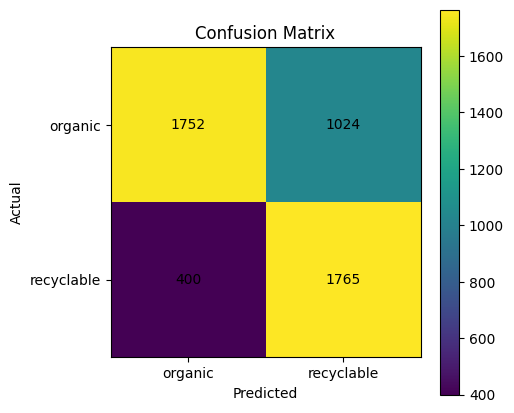

In [ ]:
cm = confusion_matrix(y_true_test, y_pred_test)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

classes = ['organic','recyclable']
plt.xticks(range(2), classes)
plt.yticks(range(2), classes)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

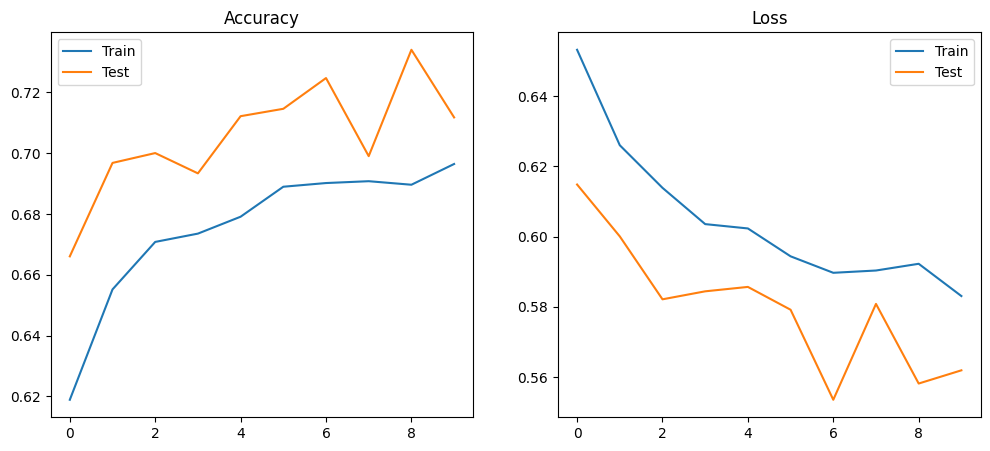

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Test'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Test'])

plt.show()

In [ ]:
model.save('/content/drive/MyDrive/resnet50_sampah.h5')
print("Model berhasil disimpan!")

Model berhasil disimpan!
